# Fase 6 — Classificação Temática Supervisionada (NÚCLEO)
**Projeto:** Deriva de Pauta nas Notícias do CNJ

Esta é a **avaliação formal** do projeto. Enquanto o BERTopic (Fase 4) *descobriu*
a taxonomia de 10 classes temáticas de forma não-supervisionada, aqui
**aprendemos e avaliamos** a classificação temática com três modelos, cobrindo
as técnicas do curso:

| Modelo | Técnica | Papel |
|---|---|---|
| **A. Naive Bayes** | TF-IDF (BoW ponderado) + `MultinomialNB` | baseline |
| **B. MLP (Keras)** | TF-IDF → `Dense`/ReLU/`Dropout`/softmax + Adam | núcleo de DL |
| **C. BERTimbau** | embeddings BERT-pt (mean-pooling) + LogReg | transformer |

> **Protocolo sem vazamento.** O rótulo de treino é **fraco** (`topic_raw` do
> BERTopic, alta confiança). O **gold humano** (`reports/gold_labels.csv`) é
> **removido do treino** — 162/173 documentos do gold também têm rótulo fraco, e
> treinar neles inflaria a métrica. Há dois regimes: **interno** (treino/val/teste
> sobre a pool de rótulos fracos) e **externo** (treina na pool inteira, prediz o
> gold humano). Toda a computação está em `src/classify.py` (+ `src/embed_bertimbau.py`
> para os embeddings BERTimbau, em processo separado por causa do conflito
> TensorFlow×PyTorch). Este notebook **apresenta** os artefatos.

Reexecute com:
```bash
python src/embed_bertimbau.py    # cache de embeddings BERTimbau (torch)
python src/classify.py --epochs 50
```

In [1]:
import json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"
M = json.load(open(PROC / "classify_metrics.json", encoding="utf-8"))
P = M["protocol"]
print("Pool de treino (rótulo fraco, fora do gold):", P["pool_size"])
print("Gold humano avaliado:", P["gold_labeled"],
      "(+%d 'indefinido' excluídos)" % P["gold_indefinido_excluded"])
print("Split interno:", P["split"])
print("Nota de vazamento:", P["leakage_note"])

Pool de treino (rótulo fraco, fora do gold): 529
Gold humano avaliado: 173 (+22 'indefinido' excluídos)
Split interno: {'treino': 338, 'val': 85, 'teste': 106}
Nota de vazamento: gold removido do treino (162/173 também eram rótulo fraco)


## 1. Comparação dos três modelos

`int_*` = regime interno (teste sobre rótulos fracos); `gold_*` = regime externo
(contra a anotação humana). `kappa` = Cohen's kappa predição×gold.

In [2]:
rows = []
for name, r in M["models"].items():
    rows.append({
        "modelo": name,
        "int_acc": r["internal"]["accuracy"],
        "int_f1_macro": r["internal"]["f1_macro"],
        "gold_acc": r["external"]["accuracy"],
        "gold_f1_macro": r["external"]["f1_macro"],
        "gold_kappa": r["external"]["kappa"],
    })
comp = pd.DataFrame(rows).set_index("modelo")
comp

,int_acc,int_f1_macro,gold_acc,gold_f1_macro,gold_kappa
modelo,,,,,
naive_bayes,0.6038,0.4292,0.5434,0.4958,0.4896
mlp_keras,0.7736,0.6863,0.8092,0.7980,0.7875
bertimbau,0.7925,0.7092,0.7919,0.7870,0.7687


**Leitura honesta dos resultados (números reais de `src/classify.py`):**

- O **Naive Bayes** é o baseline mais fraco — falha em classes pequenas (ver
  F1 por classe na seção 4).
- A **MLP** e o **BERTimbau** atingem **kappa ≈ 0,77–0,79** contra o gold humano
  (*concordância substancial* na escala de Landis & Koch), com a MLP liderando o
  F1-macro externo.
- Estes números são **mais baixos** que a validação antiga (`src/supervised.py`,
  kappa ≈ 0,91) **porque corrigimos um vazamento**: lá o gold estava no treino.
  Esta é a avaliação honesta e independente.

## 2. Modelo A — Naive Bayes (TF-IDF + MultinomialNB)

Baseline clássico do curso: **Bag-of-Words ponderado por TF-IDF** (1–2 gramas,
`max_features=5000`, stopwords institucionais) + **Naive Bayes multinomial**.

In [3]:
nb = M["models"]["naive_bayes"]
print("interno  -> acc=%.4f  f1_macro=%.4f" % (nb["internal"]["accuracy"], nb["internal"]["f1_macro"]))
print("gold     -> acc=%.4f  f1_macro=%.4f  kappa=%.4f" % (
    nb["external"]["accuracy"], nb["external"]["f1_macro"], nb["external"]["kappa"]))
print("\nF1 por classe (vs gold):")
for k, v in sorted(nb["external_per_class_f1"].items(), key=lambda x: x[1]):
    print("  %5.3f  %s" % (v, k))

interno  -> acc=0.6038  f1_macro=0.4292
gold     -> acc=0.5434  f1_macro=0.4958  kappa=0.4896

F1 por classe (vs gold):
  0.000  Precatórios / corregedoria
  0.200  Processos disciplinares / sessões
  0.261  Infância e juventude
  0.476  Saúde / judicialização / SUS
  0.482  Justiça itinerante / cidadania
  0.526  Direitos humanos / Corte IDH
  0.692  Sustentabilidade ambiental
  0.741  IA / Conecta / Justiça 4.0
  0.769  Sistema prisional / Pena Justa
  0.811  Violência doméstica / mulheres


## 3. Modelo B — MLP Keras (núcleo de Deep Learning)

Arquitetura (`src/classify.py::build_mlp`), cobrindo **camadas densas, ReLU,
Dropout, softmax e otimizador Adam**:

```python
Sequential([
    Input(shape=(n_features,)),      # TF-IDF, ~5000 features
    Dense(256, activation="relu"), Dropout(0.3),
    Dense(128, activation="relu"), Dropout(0.3),
    Dense(n_classes, activation="softmax"),
])  # loss=sparse_categorical_crossentropy, optimizer=adam
```

### 3.1 Análise de overfit/underfit e regularização (Módulo 2)

Treinamos variantes **com e sem Dropout** (mesmo nº de épocas, sem early
stopping) para comparar as curvas treino×validação.

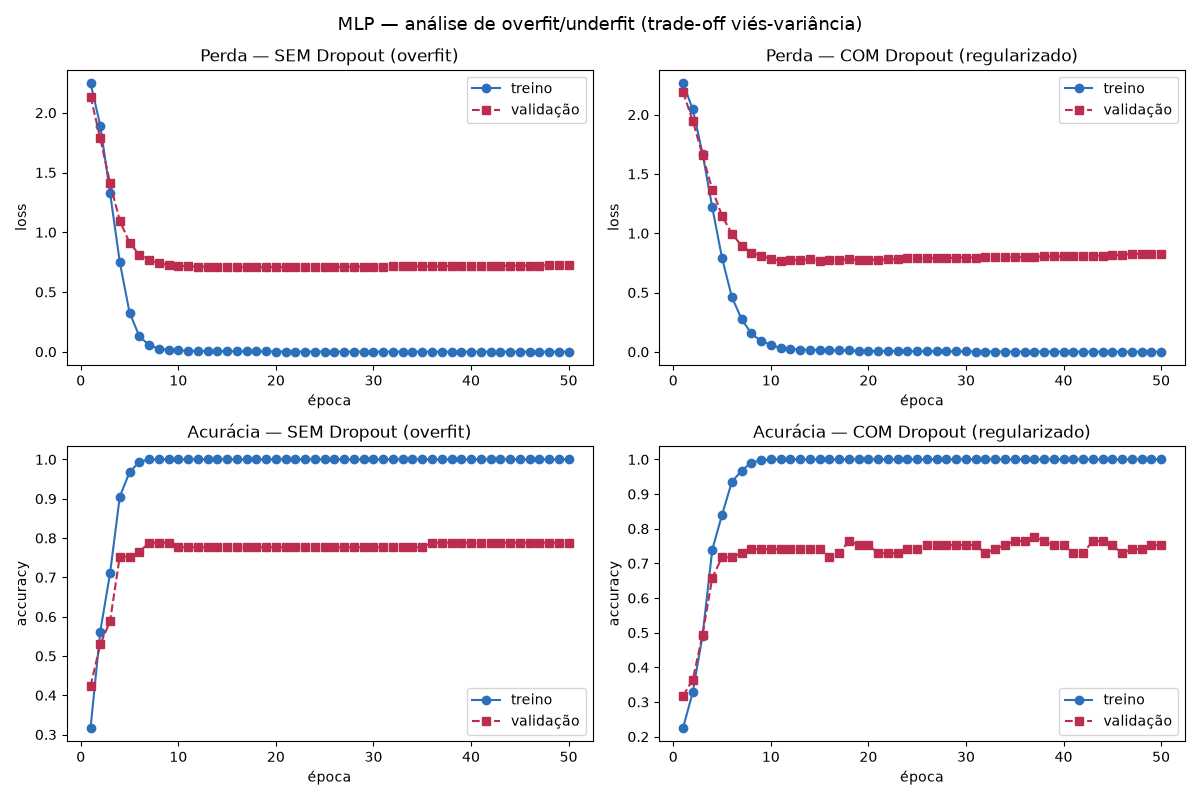

In [4]:
display(Image(filename=str(FIG / "14_overfit_mlp.png")))

**Resultado negativo, documentado (não mascarado).** O Dropout **não corrigiu**
o overfit nestas features TF-IDF esparsas com poucos dados — a subida de
`val_loss` é até **maior** com Dropout. Isto é real e esperado: zerar 30% das
unidades sobre entradas esparsas e amostra pequena adiciona ruído. Abaixo,
comparamos Dropout × **L2** × sem regularização, evidenciando o **trade-off
viés-variância**.

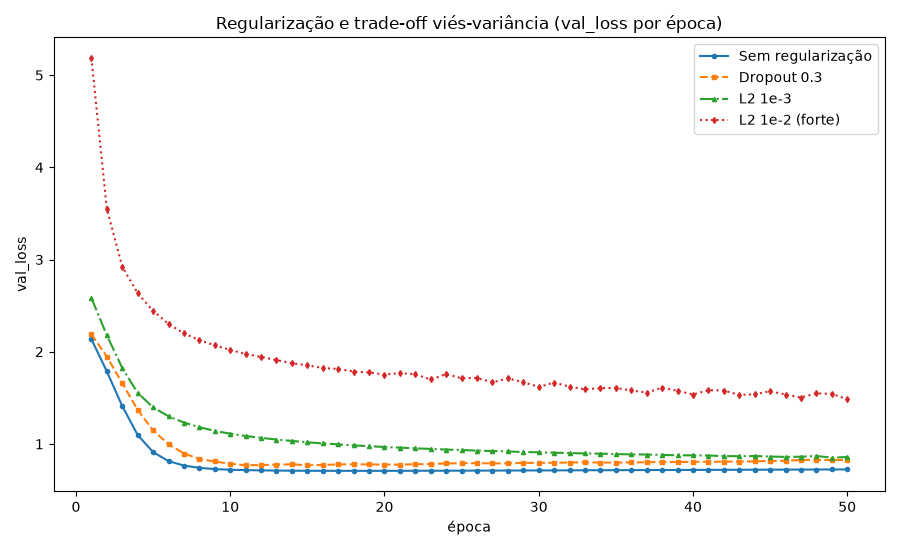

,train_acc_final,val_acc_best,val_loss_min,val_loss_final,val_loss_rise
Sem regularização,1.0000,0.7882,0.7081,0.7235,0.0155
Dropout 0.3,1.0000,0.7765,0.7686,0.8256,0.0570
L2 1e-3,1.0000,0.7765,0.8511,0.8579,0.0069
L2 1e-2 (forte),0.9941,0.7765,1.4867,1.4867,0.0000


In [5]:
display(Image(filename=str(FIG / "14b_regularizacao.png")))
reg = M["models"]["mlp_keras"]["overfit_analysis"]["regularizacao_estudo"]
pd.DataFrame(reg).T[["train_acc_final","val_acc_best","val_loss_min","val_loss_final","val_loss_rise"]]

**Interpretação (bias-variância):**

- **Sem regularização:** `train_acc=1,0` mas `val_loss` sobe após o mínimo →
  **overfit** (alta variância).
- **Dropout 0,3:** *piora* a `val_loss` aqui — regularização inadequada para o
  tipo de feature.
- **L2 1e-3:** controla melhor a subida de `val_loss` (menor `val_loss_rise`) —
  regularização que **funciona** neste caso.
- **L2 1e-2 (forte):** `val_loss` alta e estável, `val_acc` cai → **underfit**
  (alto viés): regularização forte demais.

O **modelo principal** (usado nas métricas) adota Dropout 0,3 + **EarlyStopping**
(`restore_best_weights` por `val_loss`), que é o mecanismo que de fato evita
operar na região de overfit em produção.

In [6]:
ml = M["models"]["mlp_keras"]
print("interno (modelo principal) -> acc=%.4f  f1_macro=%.4f" % (
    ml["internal"]["accuracy"], ml["internal"]["f1_macro"]))
print("gold                       -> acc=%.4f  f1_macro=%.4f  kappa=%.4f" % (
    ml["external"]["accuracy"], ml["external"]["f1_macro"], ml["external"]["kappa"]))
print("épocas treinadas (early stopping):",
      ml["overfit_analysis"]["modelo_principal_epochs"], "de", ml["overfit_analysis"]["epochs_demo"])

interno (modelo principal) -> acc=0.7736  f1_macro=0.6863
gold                       -> acc=0.8092  f1_macro=0.7980  kappa=0.7875
épocas treinadas (early stopping): 16 de 50


## 4. Modelo C — BERTimbau (transformer do curso, Módulo 4)

Embeddings de `neuralmind/bert-base-portuguese-cased` (**BERTimbau base**;
Souza et al., 2020) por **mean-pooling** da última camada sobre *título + corpo*,
seguidos de uma cabeça **Regressão Logística**. Os embeddings são computados em
processo separado (`src/embed_bertimbau.py`) por causa do conflito de runtime
TensorFlow×PyTorch.

In [7]:
bt = M["models"]["bertimbau"]
print("interno  -> acc=%.4f  f1_macro=%.4f" % (bt["internal"]["accuracy"], bt["internal"]["f1_macro"]))
print("gold     -> acc=%.4f  f1_macro=%.4f  kappa=%.4f" % (
    bt["external"]["accuracy"], bt["external"]["f1_macro"], bt["external"]["kappa"]))

interno  -> acc=0.7925  f1_macro=0.7092
gold     -> acc=0.7919  f1_macro=0.7870  kappa=0.7687


## 5. Avaliação contra o gold humano — matriz de confusão

Matrizes de confusão dos três modelos **contra a anotação humana** (não contra
os rótulos fracos). Linhas = gold; colunas = predito.

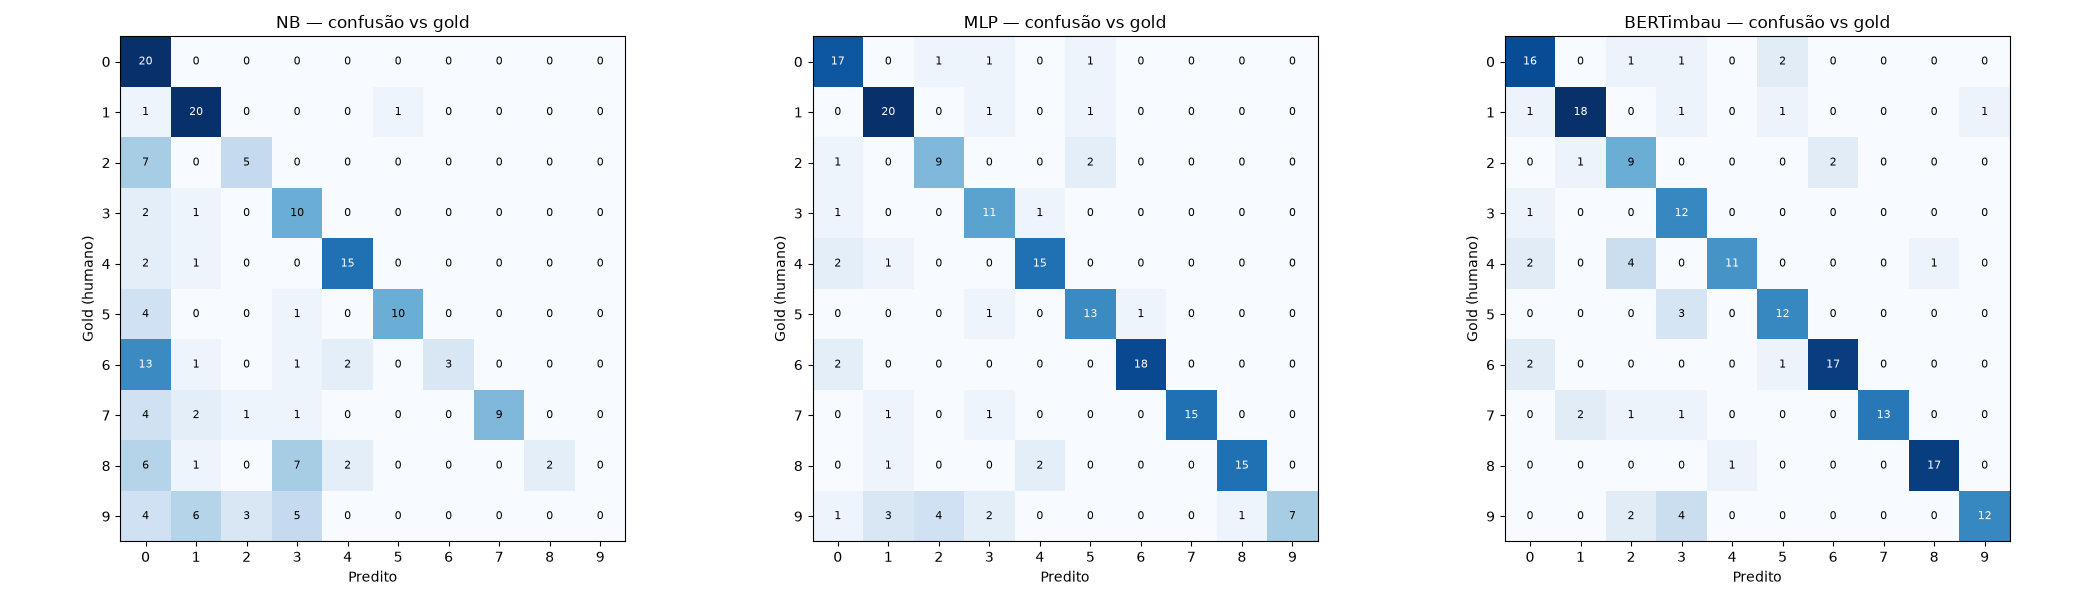

In [8]:
display(Image(filename=str(FIG / "15_confusion_gold.png")))

In [9]:
# F1 por classe (vs gold) — os três modelos lado a lado
import pandas as pd
pcf = pd.DataFrame({m: M["models"][m]["external_per_class_f1"] for m in M["models"]})
pcf.loc["__F1-macro__"] = [M["models"][m]["external"]["f1_macro"] for m in M["models"]]
pcf

,naive_bayes,mlp_keras,bertimbau
Justiça itinerante / cidadania,0.4819,0.7727,0.7619
IA / Conecta / Justiça 4.0,0.7407,0.8333,0.8372
Saúde / judicialização / SUS,0.4762,0.6923,0.6207
Direitos humanos / Corte IDH,0.5263,0.7333,0.6857
Violência doméstica / mulheres,0.8108,0.8333,0.7333
Sistema prisional / Pena Justa,0.7692,0.8125,0.7742
Infância e juventude,0.2609,0.9231,0.8718
Sustentabilidade ambiental,0.6923,0.9375,0.8667
Processos disciplinares / sessões,0.2000,0.8824,0.9444
Precatórios / corregedoria,0.0000,0.5600,0.7742


## 6. Gold set — protocolo de anotação (100% humano)

O gold usado aqui (`reports/gold_labels.csv`, 173 documentos rotulados +
22 'indefinido') foi **anotado à mão**, lendo título/lead contra a taxonomia de
10 classes; casos ambíguos são marcados `indefinido` e **excluídos das métricas**.

`src/classify.py` também gera `reports/gold_template.csv` — amostra **aleatória
estratificada por classe candidata** (~200 linhas) com a coluna `classe`
**VAZIA**, documentando o protocolo reprodutível de anotação. Esse template
**não é rotulado por máquina**; a avaliação usa o gold humano já existente.

## 6b. NER — entidades nomeadas na comunicação do CNJ (transformer)

Com o modelo de NER em português do professor
(`rhaymison/ner-portuguese-br-bert-cased`), extraímos as entidades das notícias
para mapear *quem e o quê* dominam a comunicação institucional, inclusive por
classe temática. Computação em `src/ner.py` (PyTorch, processo separado);
artefatos em `data/processed/entidades*.{parquet,csv}`.

> **Limitação declarada:** por causa do limite de 512 subtokens, processamos
> *título + lead* (1500 caracteres); entidades no fim de notícias longas podem
> escapar. Fragmentos de subpalavra mal mesclados (`##…`) são filtrados.

Reexecute com: `python src/ner.py`

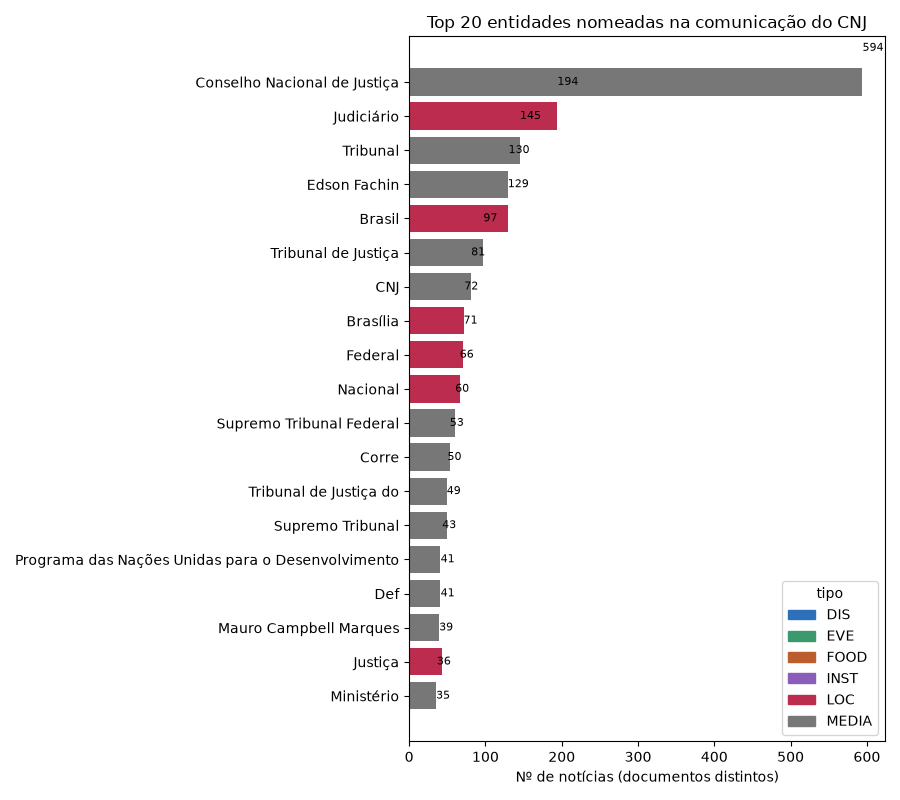

Total de entidades: 10536 | por tipo: {'LOC': 4307, 'ORG': 3408, 'PER': 1331, 'MEDIA': 1113, 'EVE': 275, 'DIS': 43, 'TIME': 41, 'INST': 16, 'PLANT': 1, 'FOOD': 1}


In [10]:
display(Image(filename=str(FIG / "16_top_entidades.png")))
ent = pd.read_parquet(PROC / "entidades.parquet")
print("Total de entidades:", len(ent), "| por tipo:",
      ent["tipo"].value_counts().to_dict())

In [11]:
# Entidade dominante por classe temática (top-3 por nº de notícias)
byc = pd.read_csv(PROC / "entidades_por_classe.csv")
top3 = (byc.sort_values(["classe_tematica", "docs"], ascending=[True, False])
           .groupby("classe_tematica")
           .apply(lambda g: " · ".join(f"{r.exemplo} ({int(r.docs)})"
                                       for r in g.head(3).itertuples()),
                  include_groups=False)
           .rename("top entidades (nº notícias)"))
top3.to_frame()

,top entidades (nº notícias)
classe_tematica,
Direitos humanos / Corte IDH,Conselho Nacional de Justiça (104) · Edson Fac...
IA / Conecta / Justiça 4.0,Conselho Nacional de Justiça (109) · Judiciári...
Infância e juventude,Conselho Nacional de Justiça (44) · Brasil (21...
Justiça itinerante / cidadania,Conselho Nacional de Justiça (61) · Tribunal (...
Precatórios / corregedoria,Conselho Nacional de Justiça (32) · Edson Fach...
Processos disciplinares / sessões,Conselho Nacional de Justiça (39) · Mauro Camp...
Saúde / judicialização / SUS,Conselho Nacional de Justiça (67) · Judiciário...
Sistema prisional / Pena Justa,Conselho Nacional de Justiça (54) · Pena Justa...
Sustentabilidade ambiental,Conselho Nacional de Justiça (23) · Tribunal (...


## 7. Mapa de cobertura do curso

| Conceito | Onde |
|---|---|
| Bag-of-Words / TF-IDF | features de NB e MLP |
| Naive Bayes | Modelo A |
| Rede densa (Keras `Sequential`/`Dense`) | Modelo B |
| ReLU, softmax | camadas da MLP |
| Adam, gradiente descendente | otimização da MLP |
| Treino/validação/teste | split estratificado (529 → 338/85/106) |
| Overfit/underfit | curvas treino×val; L2 forte = underfit |
| Regularização (Dropout, L2) | estudo da seção 3 (com resultado honesto) |
| BERTimbau / Transformers | Modelo C (+ NER, Fase 6b) |
| Embeddings | sentence-transformers (Fase 4) + BERTimbau |

## Síntese da Fase 6

- **MLP** e **BERTimbau** concordam **substancialmente** com humanos
  (kappa ≈ 0,77–0,79); NB é baseline fraco.
- Avaliação **sem vazamento** (gold fora do treino) → números honestos e
  defensáveis, abaixo da validação antiga com vazamento.
- **Overfit observado e analisado**; Dropout **não** ajudou (documentado), L2
  moderado ajudou, L2 forte gerou underfit — trade-off viés-variância explícito.
- Todos os números vêm de `data/processed/classify_metrics.json`
  (execução real de `src/classify.py`).